## 폐업 전에 위기를 감지할 수 있을까?

빅콘테스트 2025 AI·데이터 경진대회. 소상공인 가맹점 데이터(4,244개 점포, 87,826건 월별 이용정보)로 **다음 달 위기 발생 여부**를 예측하는 조기경보 모델을 개발했다.

기존 지원 정책은 폐업 이후 사후 대응에 집중돼 있다. 이 분석에서 확인하고 싶었던 것은 하나다 — **폐업 신호가 실제로 몇 달 전부터 나타나는가?**

### 분석 진행 내용
- 위기 정의 설계: 매출 급락률(`pct_change`), 3개월 평균 대비 변화율(`rel_to_avg`), 지속성(2개월 연속) 3가지 기준으로 `crisis_flag` 직접 라벨링
- 피처 엔지니어링: EDA 기반 매출 트렌드·고객 행동·상권 맥락 5개 카테고리 54개 피처 설계
- 모델링: LightGBM 베이스 → 스태킹 앙상블(LightGBM + XGBoost + CatBoost → LightGBM 메타모델)
- SHAP으로 변수 중요도 해석 — 직접 설계한 피처가 상위권 확인
- 임계값 조정으로 Recall 최대화 (위기 점포 미탐지 최소화)
- 리드타임 분석: 폐업 평균 **9.3개월 전**부터 위기 신호 감지 가능

In [1]:
import pandas as pd

df1 = pd.read_csv('공모전_전처리.csv')

In [2]:
import matplotlib.pyplot as plt
from matplotlib import rc
# 한글 폰트 설정
rc('font', family='AppleGothic')

# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [3]:
df = df1.dropna(subset=['상권'])
df

,가맹점구분번호,기준년월,가맹점운영개월수구간,매출금액구간,매출건수구간,유니크고객수구간,객단가구간,취소율구간,배달매출비율,동일업종 매출비율,...,거주 이용 고객 비율,직장 이용 고객 비율,유동인구 이용 고객 비율,남성 비중,여성 비중,업종,상권,개설일,폐업일,영업중
0,000F03E44A,202404,4,5,5,5,5,1,0.0,0.026,...,12.5,12.5,75.0,81.8181,18.0819,중식-딤섬/중식만두,뚝섬,20220225,NaN,1
1,000F03E44A,202312,4,6,6,6,6,0,0.0,0.000,...,0.0,0.0,0.0,74.9000,25.1000,중식-딤섬/중식만두,뚝섬,20220225,NaN,1
2,002816BA73,202404,2,3,4,4,2,6,0.0,0.966,...,23.8,23.8,52.4,82.4000,17.6000,요리주점,마장동,20140507,NaN,1
3,002816BA73,202411,2,3,4,4,2,6,0.0,1.080,...,11.5,11.5,76.9,79.5000,20.5000,요리주점,마장동,20140507,NaN,1
4,002816BA73,202406,2,4,4,4,2,1,0.0,0.742,...,13.0,17.4,69.6,84.0000,16.0000,요리주점,마장동,20140507,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86584,63D56CEF99,202303,4,2,3,3,3,4,34.7,1.758,...,39.6,6.6,53.8,52.7527,47.3473,한식-육류/고기,왕십리,20200529,NaN,1
86586,A7C2307794,202303,2,2,2,2,3,1,19.2,1.967,...,36.8,7.4,55.9,51.8481,48.0519,한식-두부요리,옥수,20140508,NaN,1
86587,BF6A6456AB,202407,6,2,4,4,1,6,1.6,1.763,...,16.7,41.7,41.7,60.7607,39.3393,한식-육류/고기,뚝섬,20240131,20250724.0,0
86588,C59F032CAC,202406,1,2,2,2,4,2,24.0,1.165,...,40.0,11.3,48.7,64.8000,35.2000,샌드위치/토스트,한양대,20090421,NaN,1


### **위기 정의 라벨링**

- 매출 급락률
    - 전월 대비 매출이 특정 비율 이상 급락한 경우
    - pct_change = (이번달 매출금액구간 - 지난달 매출금액구간) / 지난달 매출금액구간
    - -0.3 (30% 이상 )

- 최근 n개월 평균 대비 변화율 (rolling mean 비교)
    - 최근 n개월 평균보다 매출이 충분히 낮은 경우
    - rel_to_avg = (이번달 매출금액구간 - 최근 n개월 평균) / 최근 n개월 평균
    - 최근 3개월 평균과 비교

- 지속성 (sustained)
    - 위 상태가 2개월 이상 연속 지속된 경우 '진짜 위기(crisis_fla=1)'로 간주
    - 2개월 연속 위기면 확정

In [4]:
pct_threshold = -0.3   # 전월 대비 30% 이상 하락
n = 3                  # 최근 3개월 평균 대비
sustained = 2          # 2개월 연속 위기 지속 시 flag=1

In [5]:
import pandas as pd
import numpy as np

# 기준년월을 시계열로 변환
df['기준년월'] = pd.to_datetime(df['기준년월'], format='%Y%m')

# 가맹점별로 정렬
df = df.sort_values(by=['가맹점구분번호', '기준년월'])

# 가맹점별 매출금액구간 변화율 계산 준비
df['매출금액구간'] = df['매출금액구간'].astype(float)

# 전월 대비 변화율
df['pct_change'] = df.groupby('가맹점구분번호')['매출금액구간'].pct_change() ## 이전 달 대비(pct_change())

# 최근 n개월 평균 대비 변화율
df['rolling_mean'] = (
    ## 각 가맹점별로 최근 n개월 동안의 매출금액구간 평균값을 계산
    df.groupby('가맹점구분번호')['매출금액구간'].transform(lambda x: x.rolling(window=n, min_periods=1).mean())
)
## 현재 매출 수준이 최근 N개월 평균보다 얼마나 높거나 낮은지(%)를 계산
df['rel_to_avg'] = (df['매출금액구간'] - df['rolling_mean']) / df['rolling_mean']

# 위기 기준: 전월 대비 -30% 이상 또는 최근 평균 대비 -30% 이상 하락
df['crisis_raw'] = np.where(
    (df['pct_change'] <= pct_threshold) | (df['rel_to_avg'] <= pct_threshold),
    1,
    0
)

# 위기 지속성(sustained) 반영: sustained개월 연속 발생 시 확정 위기
def sustained_flag(series, sustained):
    sustained_list = []
    count = 0
    for val in series:
        if val == 1:
            count += 1
        else:
            count = 0
        sustained_list.append(1 if count >= sustained else 0)
    return sustained_list

df['crisis_flag'] = df.groupby('가맹점구분번호')['crisis_raw'].transform(
    lambda x: sustained_flag(x, sustained)
)

# 불필요한 중간 컬럼 정리
df = df.drop(columns=['rolling_mean', 'crisis_raw'])

# 결과 확인
df[['가맹점구분번호', '기준년월', '매출금액구간', 'pct_change', 'rel_to_avg', 'crisis_flag']]

/var/folders/2w/2z4q8csj44n7n7864g6q6b2r0000gn/T/ipykernel_71355/1881263812.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['기준년월'] = pd.to_datetime(df['기준년월'], format='%Y%m')


,가맹점구분번호,기준년월,매출금액구간,pct_change,rel_to_avg,crisis_flag
46117,000F03E44A,2023-01-01,6.0,NaN,0.00,0
27145,000F03E44A,2023-02-01,6.0,0.0,0.00,0
27144,000F03E44A,2023-03-01,6.0,0.0,0.00,0
51842,000F03E44A,2023-04-01,6.0,0.0,0.00,0
34110,000F03E44A,2023-05-01,6.0,0.0,0.00,0
...,...,...,...,...,...,...
81837,FFF0DAC445,2024-08-01,2.0,1.0,0.20,0
19731,FFF0DAC445,2024-09-01,1.0,-0.5,-0.25,0
34109,FFF0DAC445,2024-10-01,2.0,1.0,0.20,0
40932,FFF0DAC445,2024-11-01,2.0,0.0,0.20,0


### **타깃 변수 생성**

> 현재까지의 데이터를 보고, ***다음 달 위기 발생 여부***를 예측하도록 만들기

- 다음 달에 위기가 왔는지 정답(label)을 만들어줘야 함

1. 현재 월 기준으로 한 달 뒤의 crisis_flag 값을 타깃으로 설정

2. 가맹점별로 따로 계산
    - 각 점포의 시계열은 독립적이기에, '가맹점구분번호'를 기준으로 그룹한 후 shift(-1)을 적용

3. 마지막 달은 미래 데이터가 없기에 NaN -> 제거

In [6]:
# 가맹점별로 한 달 뒤 crisis_flag를 타깃으로 이동
df['next_month_crisis'] = (
    df.groupby('가맹점구분번호')['crisis_flag']
    .shift(-1)
)

# 마지막 달은 미래 데이터가 없으므로 제거
df = df.dropna(subset=['next_month_crisis'])

# 정수형으로 변환
df['next_month_crisis'] = df['next_month_crisis'].astype(int)

# 확인
df[['가맹점구분번호', '기준년월', 'crisis_flag', 'next_month_crisis']]

,가맹점구분번호,기준년월,crisis_flag,next_month_crisis
46117,000F03E44A,2023-01-01,0,0
27145,000F03E44A,2023-02-01,0,0
27144,000F03E44A,2023-03-01,0,0
51842,000F03E44A,2023-04-01,0,0
34110,000F03E44A,2023-05-01,0,0
...,...,...,...,...
68471,FFF0DAC445,2024-07-01,0,0
81837,FFF0DAC445,2024-08-01,0,0
19731,FFF0DAC445,2024-09-01,0,0
34109,FFF0DAC445,2024-10-01,0,0


In [7]:
df['crisis_flag'].value_counts()

crisis_flag
0    61683
1      350
Name: count, dtype: int64

In [8]:
df['next_month_crisis'].value_counts()

next_month_crisis
0    61658
1      375
Name: count, dtype: int64

### **피처 엔지니어링**

- 위기(1)를 미리 감지할 수 있는 신호 만드는 과정

> 목표 : 현재 월의 다양한 정보를 조합해 다음 달 위기 발생을 미리 예측할 수 있도록!

1. 매출 트렌드

2. 고객 행동

3. 상권/업종 맥락

4. 순위 지표

1. 매출 트렌드 피처
- 매출_3개월평균 : 최근 평균 수준

- 매출_3개월표준편차 : 변동성 크면 불안정 시장

- 매출_3개월기울기 : 하락 추세 면 위험 신호

In [9]:

# 가맹점별 정렬
df = df.sort_values(['가맹점구분번호', '기준년월'])

# 전월 대비 매출금액구간 변화율 (이미 있음)
# 3개월 이동평균 및 표준편차
df['매출_3개월평균'] = (
    df.groupby('가맹점구분번호')['매출금액구간']
      .transform(lambda x: x.rolling(3, min_periods=1).mean())
)
df['매출_3개월표준편차'] = (
    df.groupby('가맹점구분번호')['매출금액구간']
      .transform(lambda x: x.rolling(3, min_periods=1).std())
)

# 최근 3개월 추세선 기울기(단순회귀)
from sklearn.linear_model import LinearRegression
def calc_slope(series):
    if len(series) < 3:
        return np.nan
    X = np.arange(len(series)).reshape(-1,1)
    y = series.values
    model = LinearRegression().fit(X, y)
    return model.coef_[0]

df['매출_3개월기울기'] = (
    df.groupby('가맹점구분번호')['매출금액구간']
      .transform(lambda x: x.rolling(3, min_periods=3).apply(calc_slope, raw=False))
)


2. 고객 행동 피처
- 재방문율 하락 → 고객 충성도 약화

- 신규율 급등 → 기존 고객 이탈 가능성

- 유동비율 > 0.5 → 폐업률 급등 구간 (EDA 근거)

In [10]:
# 재방문율 변화, 신규율 변화
df['재방문율_증감'] = df.groupby('가맹점구분번호')['재방문 고객 비중'].diff()
df['신규율_증감'] = df.groupby('가맹점구분번호')['신규 고객 비중'].diff()

# 유동인구 이용 고객 비율의 비선형 효과 반영
df['유동비율_편차제곱'] = (df['유동인구 이용 고객 비율'] - 0.5)**2


3. 상권/업종 맥락 피처
- 상권/업종에 따라 구조적 위험이 다름.

- 평균 폐업률을 피처로 두면 '환경 위험'정보 내포

In [11]:
# 업종·상권별 평균 폐업률 (집단 위험도)
df['업종별_평균폐업률'] = df.groupby('업종')['next_month_crisis'].transform('mean')
df['상권별_평균폐업률'] = df.groupby('상권')['next_month_crisis'].transform('mean')

# 업종, 상권을 Label Encoding (모델 입력용)
from sklearn.preprocessing import LabelEncoder
for col in ['업종', '상권']:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col])


4. 순위 지표 피처
- 순위가 계속 하락 → 상대적 경쟁력 악화

- EDA 에서 폐업점 순위 하락 확인됨

In [12]:
# 업종·상권 내 매출 순위 비율의 변화량
df['업종순위_변화'] = df.groupby('가맹점구분번호')['동일 업종 내 매출 순위 비율'].diff()
df['상권순위_변화'] = df.groupby('가맹점구분번호')['동일 상권 내 매출 순위 비율'].diff()

5. 고객 구성 변화율 피처
- “최근 몇 달 사이 고객 연령 구성의 변화가 위기와 어떤 상관이 있는가”를 포착

* 고객 연령대 컬럼 정리

In [13]:
# 1️⃣ 연령대별 비율 합산 (성별 구분 없이)
df['연령_20대이하'] = df['남성 20대이하 고객 비중'] + df['여성 20대이하 고객 비중']
df['연령_30대'] = df['남성 30대 고객 비중'] + df['여성 30대 고객 비중']
df['연령_40대'] = df['남성 40대 고객 비중'] + df['여성 40대 고객 비중']
df['연령_50대'] = df['남성 50대 고객 비중'] + df['여성 50대 고객 비중']
df['연령_60대이상'] = df['남성 60대이상 고객 비중'] + df['여성 60대이상 고객 비중']

# 2️⃣ 전체 비율 합 (정규화용)
df['총연령비율'] = (
    df['연령_20대이하'] + df['연령_30대'] +
    df['연령_40대'] + df['연령_50대'] + df['연령_60대이상']
)

# 3️⃣ 표준화된 비율 (비중 합이 1이 되도록)
for col in ['연령_20대이하', '연령_30대', '연령_40대', '연령_50대', '연령_60대이상']:
    df[col + '_비중'] = df[col] / df['총연령비율']

# 4️⃣ 필요 없는 중간 컬럼 정리
df = df.drop(columns=['총연령비율'])

In [14]:
# 최근 3개월 기준 변화율 계산
age_cols = ['연령_20대이하', '연령_30대', '연령_40대', '연령_50대', '연령_60대이상']

for col in age_cols:
    df[f'{col}_3개월변화'] = (
        df.groupby('가맹점구분번호')[col]
          .transform(lambda x: x.rolling(3, min_periods=2).apply(lambda s: s.iloc[-1] - s.iloc[0]))
    )

In [15]:
df.to_csv("백업데이터.csv", index=False, encoding="utf-8-sig")

In [16]:
df_model = pd.read_csv('백업데이터.csv')
df_model

,가맹점구분번호,기준년월,가맹점운영개월수구간,매출금액구간,매출건수구간,유니크고객수구간,객단가구간,취소율구간,배달매출비율,동일업종 매출비율,...,연령_20대이하_비중,연령_30대_비중,연령_40대_비중,연령_50대_비중,연령_60대이상_비중,연령_20대이하_3개월변화,연령_30대_3개월변화,연령_40대_3개월변화,연령_50대_3개월변화,연령_60대이상_3개월변화
0,000F03E44A,2023-01-01,5,6.0,5,5,4,1,0.0,0.005,...,0.000000,0.000000,0.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN
1,000F03E44A,2023-02-01,5,6.0,6,6,6,0,0.0,0.000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.0,0.0,0.0,0.0,0.0
2,000F03E44A,2023-03-01,5,6.0,6,6,6,0,0.0,0.000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.0,0.0,0.0,0.0,0.0
3,000F03E44A,2023-04-01,5,6.0,5,5,3,1,0.0,0.013,...,0.000000,0.500000,0.000000,0.500000,0.000000,0.0,50.0,0.0,-50.0,0.0
4,000F03E44A,2023-05-01,5,6.0,5,5,6,1,0.0,0.000,...,0.000000,0.667000,0.000000,0.333000,0.000000,0.0,66.7,0.0,-66.7,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62028,FFF0DAC445,2024-07-01,3,1.0,2,2,3,1,0.0,4.040,...,0.415415,0.370370,0.113113,0.077077,0.024024,-0.5,-0.4,0.9,0.1,-0.1
62029,FFF0DAC445,2024-08-01,3,2.0,3,3,3,1,0.0,2.948,...,0.412587,0.374625,0.119880,0.069930,0.022977,-0.7,0.4,1.3,-0.6,-0.4
62030,FFF0DAC445,2024-09-01,3,1.0,3,2,2,5,0.0,4.243,...,0.409590,0.378621,0.116883,0.072927,0.021978,-0.5,0.9,0.4,-0.4,-0.2
62031,FFF0DAC445,2024-10-01,3,2.0,3,2,3,1,0.0,3.336,...,0.403000,0.388000,0.114000,0.072000,0.023000,-1.0,1.3,-0.6,0.2,0.0


### **컬럼 정리**

In [17]:
# drop_cols = ['가맹점구분번호', '기준년월', '개설일', '폐업일']
# df_model = df.drop(columns=[c for c in drop_cols if c in df.columns])

In [18]:
import numpy as np
import pandas as pd

# 1️⃣ 상관계수 행렬 계산
corr_matrix = df_model.corr(numeric_only=True).abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 2️⃣ 각 상관쌍 중 하나만 남기기
to_drop = set()
for col in upper.columns:
    high_corr = upper.index[upper[col] > 0.9].tolist()
    for pair in high_corr:
        # 이미 제거 리스트에 있으면 넘어감
        if pair in to_drop or col in to_drop:
            continue

        # 분산이 더 큰 쪽을 남기고, 작은 쪽 제거
        var_col = df_model[col].var()
        var_pair = df_model[pair].var()
        if var_col >= var_pair:
            to_drop.add(pair)
        else:
            to_drop.add(col)

print(f"📊 삭제된 고상관 컬럼 수: {len(to_drop)}")
print(f"🗑️ 삭제 목록: {list(to_drop)}")

# 3️⃣ 실제 제거
df_model_reduced = df_model.drop(columns=list(to_drop), errors='ignore')


📊 삭제된 고상관 컬럼 수: 10
🗑️ 삭제 목록: ['매출_3개월평균', '가맹점운영개월수구간', '연령_50대_비중', '연령_40대_비중', '연령_60대이상_비중', '매출건수구간', '유동인구 이용 고객 비율', '동일 상권 내 매출 순위 비율', '연령_20대이하_비중', '연령_30대_비중']


In [19]:
# from statsmodels.stats.outliers_influence import variance_inflation_factor
# from statsmodels.tools.tools import add_constant
# import pandas as pd
# import numpy as np

# def stepwise_vif(df, thresh=10.0, max_iter=50):
#     """
#     ⚙️ VIF 단계적 제거 함수 (수치형 컬럼만 사용)
#     - 입력: DataFrame
#     - 출력: (최종 df, 제거된 컬럼 목록, 최종 VIF 테이블)
#     """
#     # 1️⃣ 수치형 컬럼만 선택
#     df_vif = df.select_dtypes(include=[np.number]).copy()

#     # 2️⃣ NaN / inf 처리
#     df_vif = df_vif.replace([np.inf, -np.inf], np.nan)
#     df_vif = df_vif.fillna(df_vif.median())

#     features = df_vif.columns.tolist()
#     dropped = []
#     iteration = 0

#     while iteration < max_iter and len(features) > 1:
#         iteration += 1
#         X = add_constant(df_vif[features])
#         vifs = []

#         for i in range(1, X.shape[1]):  # const 제외
#             vifs.append(variance_inflation_factor(X.values, i))

#         vif_series = pd.Series(vifs, index=features, name="VIF").sort_values(ascending=False)

#         max_feat, max_vif = vif_series.index[0], float(vif_series.iloc[0])
#         print(f"🔁 Iter {iteration}: {max_feat} (VIF={max_vif:.2f})")

#         if max_vif > thresh:
#             print(f"⚠️ {max_feat} 제거 (VIF={max_vif:.2f})")
#             features.remove(max_feat)
#             dropped.append((max_feat, max_vif))
#         else:
#             break

#     final_df = df_vif[features].copy()
#     X_final = add_constant(final_df)
#     final_vif = pd.Series(
#         [variance_inflation_factor(X_final.values, i) for i in range(1, X_final.shape[1])],
#         index=final_df.columns,
#         name="VIF"
#     ).sort_values(ascending=False)

#     print("\n✅ VIF 단계적 제거 완료")
#     print(f"남은 피처 수: {len(features)}")
#     print(f"제거된 피처 수: {len(dropped)}")

#     return final_df, dropped, final_vif


In [20]:
# # df_model_reduced는 상관계수 0.9 초과 컬럼 제거 후 데이터프레임
# df_vif_final, dropped_vif, final_vif = stepwise_vif(df_model_reduced, thresh=10.0)

In [21]:
df_model_reduced

,가맹점구분번호,기준년월,매출금액구간,유니크고객수구간,객단가구간,취소율구간,배달매출비율,동일업종 매출비율,동일업종 매출건수 비율,동일 업종 내 매출 순위 비율,...,연령_20대이하,연령_30대,연령_40대,연령_50대,연령_60대이상,연령_20대이하_3개월변화,연령_30대_3개월변화,연령_40대_3개월변화,연령_50대_3개월변화,연령_60대이상_3개월변화
0,000F03E44A,2023-01-01,6.0,5,4,1,0.0,0.005,0.011,95.3,...,0.0,0.0,0.0,100.0,0.0,NaN,NaN,NaN,NaN,NaN
1,000F03E44A,2023-02-01,6.0,6,6,0,0.0,0.000,0.000,95.2,...,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0
2,000F03E44A,2023-03-01,6.0,6,6,0,0.0,0.000,0.000,95.0,...,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0
3,000F03E44A,2023-04-01,6.0,5,3,1,0.0,0.013,0.010,94.5,...,0.0,50.0,0.0,50.0,0.0,0.0,50.0,0.0,-50.0,0.0
4,000F03E44A,2023-05-01,6.0,5,6,1,0.0,0.000,0.010,94.6,...,0.0,66.7,0.0,33.3,0.0,0.0,66.7,0.0,-66.7,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62028,FFF0DAC445,2024-07-01,1.0,2,3,1,0.0,4.040,4.819,2.7,...,41.5,37.0,11.3,7.7,2.4,-0.5,-0.4,0.9,0.1,-0.1
62029,FFF0DAC445,2024-08-01,2.0,3,3,1,0.0,2.948,3.617,2.8,...,41.3,37.5,12.0,7.0,2.3,-0.7,0.4,1.3,-0.6,-0.4
62030,FFF0DAC445,2024-09-01,1.0,2,2,5,0.0,4.243,4.562,2.7,...,41.0,37.9,11.7,7.3,2.2,-0.5,0.9,0.4,-0.4,-0.2
62031,FFF0DAC445,2024-10-01,2.0,2,3,1,0.0,3.336,3.866,2.7,...,40.3,38.8,11.4,7.2,2.3,-1.0,1.3,-0.6,0.2,0.0


In [22]:
# df_model_reduced['next_month_crisis'] = df['next_month_crisis']
df_model_reduced.to_csv('모델용_최종데이터2.csv', index=False)

# 모델링

In [23]:
df = pd.read_csv('모델용_최종데이터2.csv')
df

,가맹점구분번호,기준년월,매출금액구간,유니크고객수구간,객단가구간,취소율구간,배달매출비율,동일업종 매출비율,동일업종 매출건수 비율,동일 업종 내 매출 순위 비율,...,연령_20대이하,연령_30대,연령_40대,연령_50대,연령_60대이상,연령_20대이하_3개월변화,연령_30대_3개월변화,연령_40대_3개월변화,연령_50대_3개월변화,연령_60대이상_3개월변화
0,000F03E44A,2023-01-01,6.0,5,4,1,0.0,0.005,0.011,95.3,...,0.0,0.0,0.0,100.0,0.0,NaN,NaN,NaN,NaN,NaN
1,000F03E44A,2023-02-01,6.0,6,6,0,0.0,0.000,0.000,95.2,...,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0
2,000F03E44A,2023-03-01,6.0,6,6,0,0.0,0.000,0.000,95.0,...,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0
3,000F03E44A,2023-04-01,6.0,5,3,1,0.0,0.013,0.010,94.5,...,0.0,50.0,0.0,50.0,0.0,0.0,50.0,0.0,-50.0,0.0
4,000F03E44A,2023-05-01,6.0,5,6,1,0.0,0.000,0.010,94.6,...,0.0,66.7,0.0,33.3,0.0,0.0,66.7,0.0,-66.7,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62028,FFF0DAC445,2024-07-01,1.0,2,3,1,0.0,4.040,4.819,2.7,...,41.5,37.0,11.3,7.7,2.4,-0.5,-0.4,0.9,0.1,-0.1
62029,FFF0DAC445,2024-08-01,2.0,3,3,1,0.0,2.948,3.617,2.8,...,41.3,37.5,12.0,7.0,2.3,-0.7,0.4,1.3,-0.6,-0.4
62030,FFF0DAC445,2024-09-01,1.0,2,2,5,0.0,4.243,4.562,2.7,...,41.0,37.9,11.7,7.3,2.2,-0.5,0.9,0.4,-0.4,-0.2
62031,FFF0DAC445,2024-10-01,2.0,2,3,1,0.0,3.336,3.866,2.7,...,40.3,38.8,11.4,7.2,2.3,-1.0,1.3,-0.6,0.2,0.0


# 전처리

In [24]:
df.columns

Index(['가맹점구분번호', '기준년월', '매출금액구간', '유니크고객수구간', '객단가구간', '취소율구간', '배달매출비율',
       '동일업종 매출비율', '동일업종 매출건수 비율', '동일 업종 내 매출 순위 비율', '동일 업종 내 해지 가맹점 비중',
       '동일 상권 내 해지 가맹점 비중', '남성 20대이하 고객 비중', '남성 30대 고객 비중', '남성 40대 고객 비중',
       '남성 50대 고객 비중', '남성 60대이상 고객 비중', '여성 20대이하 고객 비중', '여성 30대 고객 비중',
       '여성 40대 고객 비중', '여성 50대 고객 비중', '여성 60대이상 고객 비중', '재방문 고객 비중',
       '신규 고객 비중', '거주 이용 고객 비율', '직장 이용 고객 비율', '남성 비중', '여성 비중', '업종', '상권',
       '개설일', '폐업일', '영업중', 'pct_change', 'rel_to_avg', 'crisis_flag',
       'next_month_crisis', '매출_3개월표준편차', '매출_3개월기울기', '재방문율_증감', '신규율_증감',
       '유동비율_편차제곱', '업종별_평균폐업률', '상권별_평균폐업률', '업종_encoded', '상권_encoded',
       '업종순위_변화', '상권순위_변화', '연령_20대이하', '연령_30대', '연령_40대', '연령_50대',
       '연령_60대이상', '연령_20대이하_3개월변화', '연령_30대_3개월변화', '연령_40대_3개월변화',
       '연령_50대_3개월변화', '연령_60대이상_3개월변화'],
      dtype='object')

In [25]:
print(len(df.columns))

58


In [26]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from lightgbm import log_evaluation, early_stopping
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve, roc_curve,
    precision_score, recall_score, f1_score
)

# -----------------------------
# 1️⃣ 데이터 로드 및 전처리
# -----------------------------
df = pd.read_csv('모델용_최종데이터2.csv')
print("✅ 불러온 데이터 크기:", df.shape)

ID = '가맹점구분번호'
DATE = '기준년월'
TARGET = 'next_month_crisis'

# 날짜 파싱 (2023-01-01 형태)
df[DATE] = pd.to_datetime(df[DATE], errors='coerce')
print("📅 기간:", df[DATE].min(), "→", df[DATE].max())

# -----------------------------
# 2️⃣ Train/Test Split (옵션 A: 순수 시계열)
# -----------------------------
months = np.sort(df[DATE].dropna().dt.to_period('M').unique())
test_months = months[-3:] if len(months) >= 3 else months[-1:]
print("🗓️ 테스트 대상 월:", list(map(str, test_months)))

# 마스크 생성
is_test_month = df[DATE].dt.to_period('M').isin(test_months)
train_mask = ~is_test_month
test_mask = is_test_month

# -----------------------------
# 3️⃣ Split 후 불필요 컬럼 제거
# -----------------------------
drop_cols = [ID, DATE, '폐업일']  # ✅ 폐업일 추가

X = df.drop(columns=[TARGET], errors='ignore')
y = df[TARGET].astype(int)

X_train, y_train = X.loc[train_mask].copy(), y.loc[train_mask].copy()
X_test,  y_test  = X.loc[test_mask].copy(),  y.loc[test_mask].copy()

X_train.drop(columns=drop_cols, inplace=True, errors='ignore')
X_test.drop(columns=drop_cols, inplace=True, errors='ignore')

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# -----------------------------
# 4️⃣ 데이터 타입 정리 (object → category)
# -----------------------------
for c in X_train.select_dtypes('object').columns:
    X_train[c] = X_train[c].astype('category')
    X_test[c]  = X_test[c].astype('category')



✅ 불러온 데이터 크기: (62033, 58)
📅 기간: 2023-01-01 00:00:00 → 2024-11-01 00:00:00
🗓️ 테스트 대상 월: ['2024-09', '2024-10', '2024-11']
Train: (52851, 54), Test: (9182, 54)


# 베이스모델 : recall : 0.714

[LightGBM] [Warning] min_gain_to_split is set=0.0, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.0
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] min_gain_to_split is set=0.0, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.0
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] Number of positive: 312, number of negative: 52539
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007608 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9803
[LightGBM] [Info] Number of data points in the train set: 52851, number of used features: 52
[LightGBM] [Warning] min_gain_to_split is set=0.0, min_split_gain=0.0 will

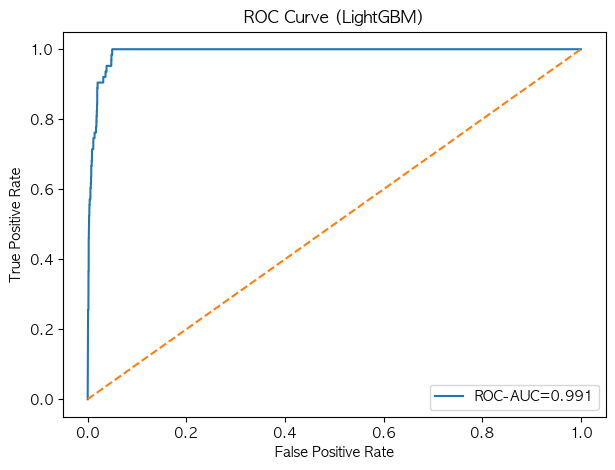

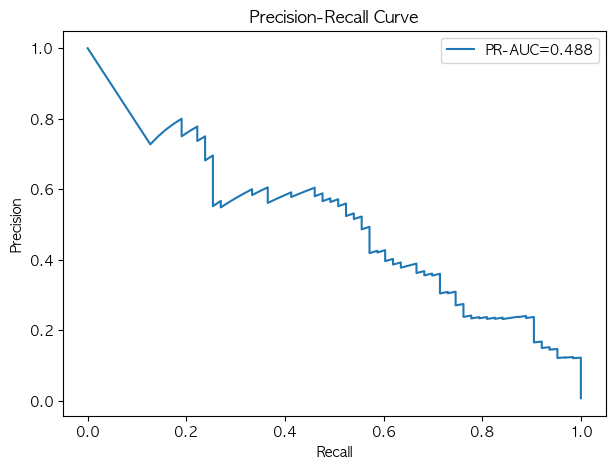

In [27]:
# -----------------------------
# 5️⃣ LightGBM 학습
# -----------------------------
model = lgb.LGBMClassifier(
    objective='binary',
    learning_rate=0.03,
    n_estimators=2000,
    max_depth=-1,
    num_leaves=15,
    min_data_in_leaf=5,
    min_gain_to_split=0.0,
    class_weight='balanced',
    random_state=42
)

use_cols = [c for c in X_train.columns if c not in ['업종', '상권']]

model.fit(
    X_train[use_cols], y_train,
    eval_set=[(X_test[use_cols], y_test)],   # ✅ 동일한 컬럼만 사용
    eval_metric='auc',
    callbacks=[log_evaluation(50), early_stopping(100)]
)

# -----------------------------
# 6️⃣ 예측 및 평가
# -----------------------------
proba = model.predict_proba(X_test[use_cols])[:, 1]  # ✅ 동일한 컬럼만 사용
roc = roc_auc_score(y_test, proba)
pr_auc = average_precision_score(y_test, proba)

precision, recall, thresholds = precision_recall_curve(y_test, proba)
beta = 2
# thresholds 길이는 precision/recall보다 1 작으므로 [1:] 정렬은 OK
f2 = (1 + beta**2) * precision[1:] * recall[1:] / (beta**2 * precision[1:] + recall[1:] + 1e-12)
best_i = np.nanargmax(f2)
best_thr = thresholds[best_i]
y_pred = (proba >= best_thr).astype(int)

print("\n=== 📊 Evaluation Results ===")
print(f"ROC-AUC: {roc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")
print(f"Best threshold (F2): {best_thr:.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall: {recall_score(y_test, y_pred):.3f}")
print(f"F1: {f1_score(y_test, y_pred):.3f}")


# -----------------------------
# 7️⃣ 시각화
# -----------------------------
plt.figure(figsize=(7,5))
fpr, tpr, _ = roc_curve(y_test, proba)
plt.plot(fpr, tpr, label=f'ROC-AUC={roc:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve (LightGBM)")
plt.legend(); plt.show()

plt.figure(figsize=(7,5))
plt.plot(recall, precision, label=f'PR-AUC={pr_auc:.3f}')
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(); plt.show()

SHAP 대상 샘플 수: 2000 / 피처 수: 52


/var/folders/2w/2z4q8csj44n7n7864g6q6b2r0000gn/T/ipykernel_71355/1797175358.py:58: UserWarning: [SHAP] 새 API 실패 → 구 API로 폴백합니다. 이유: Only model_output="raw" is supported for feature_perturbation="tree_path_dependent"
  warnings.warn(f"[SHAP] 새 API 실패 → 구 API로 폴백합니다. 이유: {e}")
/Users/sonak_bee/miniforge3/envs/project/lib/python3.10/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/var/folders/2w/2z4q8csj44n7n7864g6q6b2r0000gn/T/ipykernel_71355/1797175358.py:85: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) AppleGothic.
  plt.tight_layout(); plt.show()
/Users/sonak_bee/miniforge3/envs/project/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


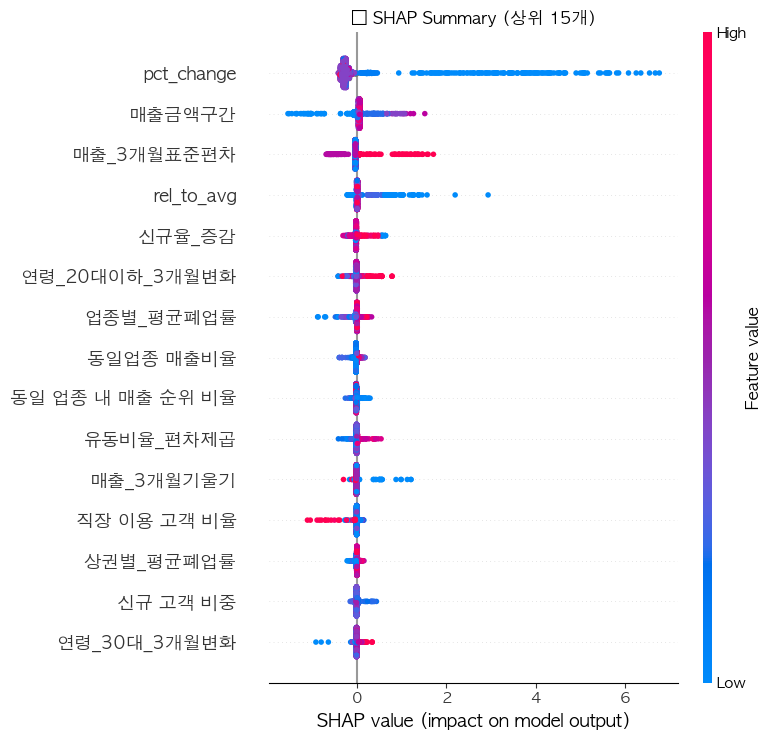

/var/folders/2w/2z4q8csj44n7n7864g6q6b2r0000gn/T/ipykernel_71355/1797175358.py:96: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) AppleGothic.
  plt.tight_layout(); plt.show()
/Users/sonak_bee/miniforge3/envs/project/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


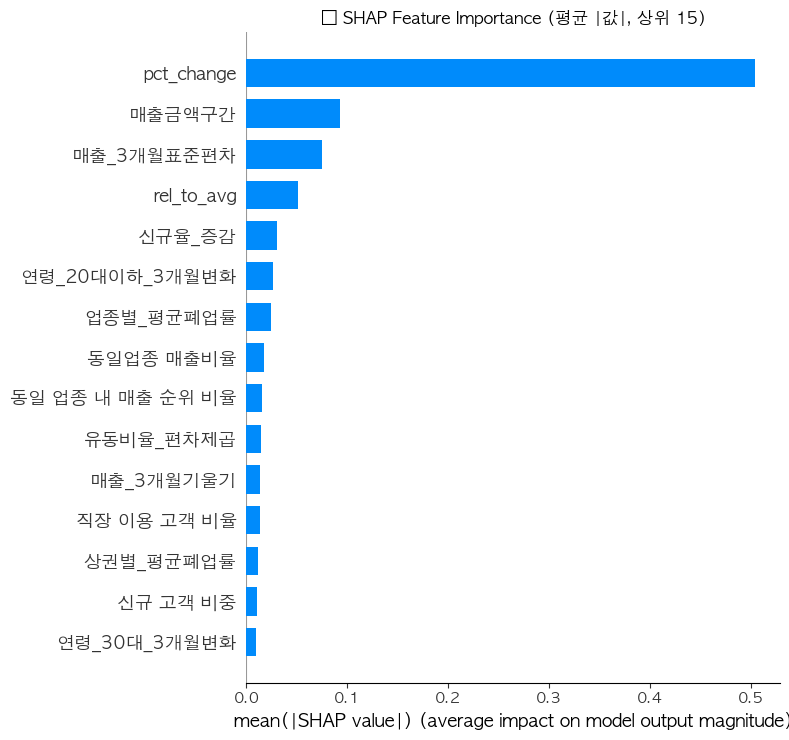

/var/folders/2w/2z4q8csj44n7n7864g6q6b2r0000gn/T/ipykernel_71355/1797175358.py:111: UserWarning: Glyph 128270 (\N{RIGHT-POINTING MAGNIFYING GLASS}) missing from font(s) AppleGothic.
  plt.tight_layout(); plt.show()
/Users/sonak_bee/miniforge3/envs/project/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128270 (\N{RIGHT-POINTING MAGNIFYING GLASS}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


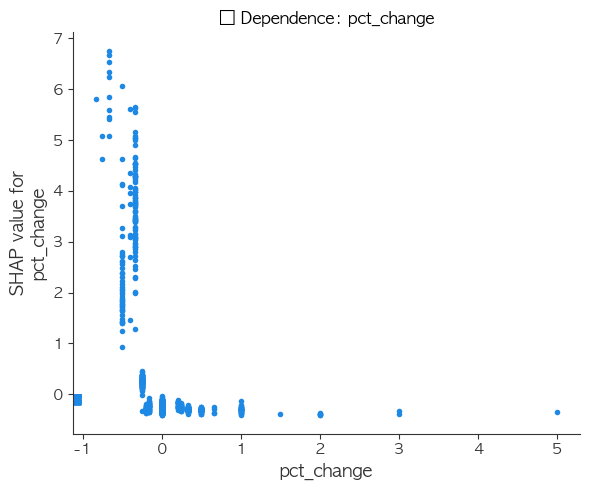

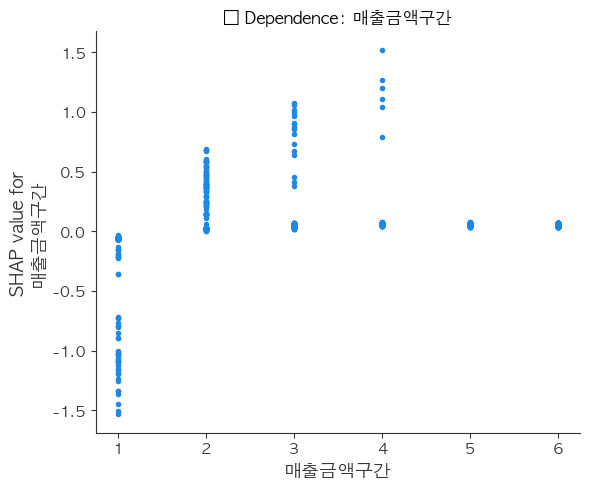

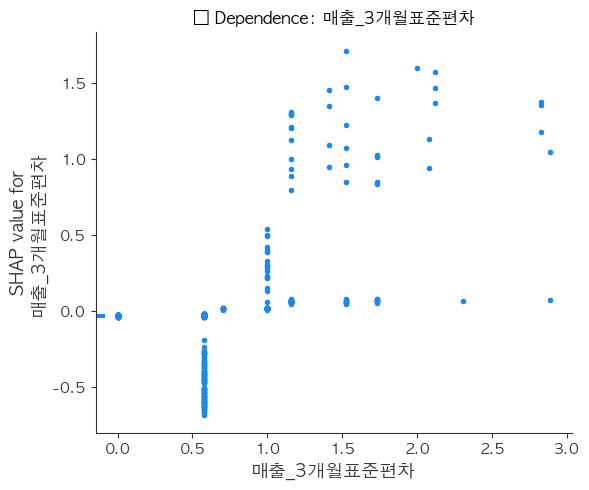

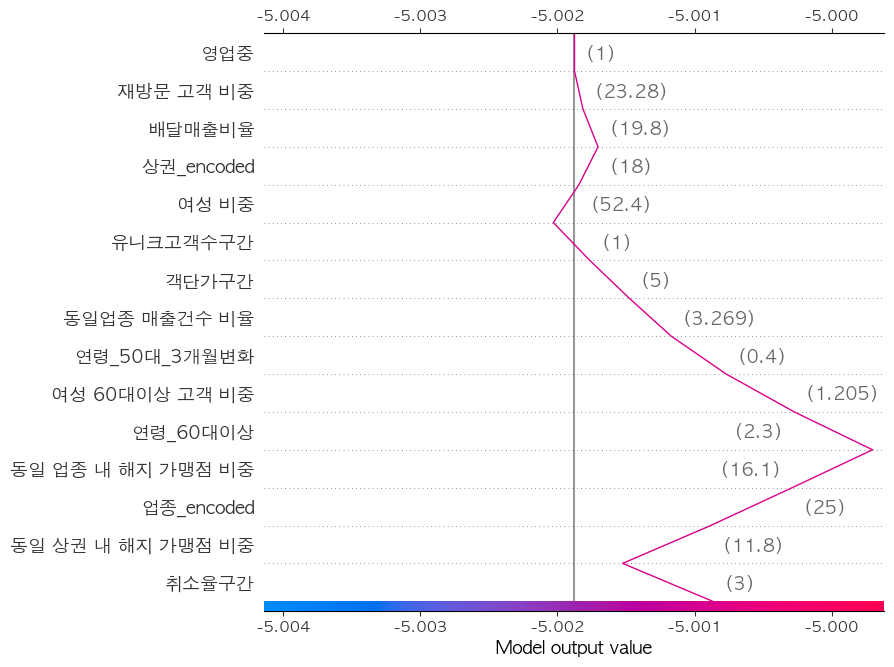

/var/folders/2w/2z4q8csj44n7n7864g6q6b2r0000gn/T/ipykernel_71355/1797175358.py:132: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) AppleGothic.
  plt.tight_layout(); plt.show()
/Users/sonak_bee/miniforge3/envs/project/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


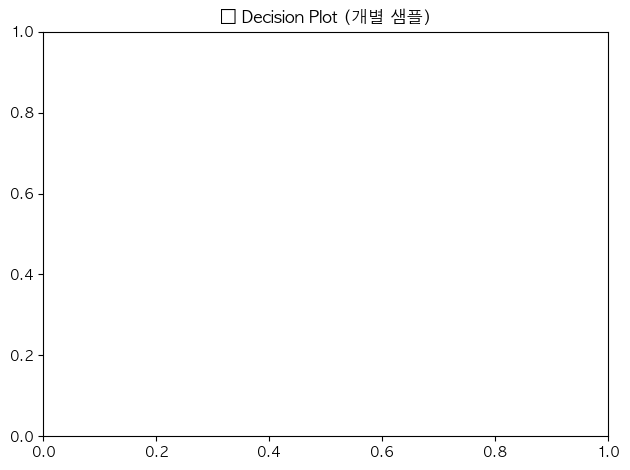

✅ SHAP 해석 완료


In [28]:
# ============================
# SHAP 전체 코드 (안전/일관 버전)
# ============================
import numpy as np
import shap
import warnings
import matplotlib.pyplot as plt

# (옵션) notebook이 아닐 때 display 미정의 에러 방지
try:
    from IPython.display import display
except Exception:
    def display(*args, **kwargs): pass

# ----------------------------
# 0) 학습에 사용한 피처셋 일치시키기
#    - 학습 시 만든 use_cols를 그대로 재사용하는 것이 가장 안전
#    - 없다면 아래 한 줄로 재생성(업종/상권만 제외)하되, 훈련 시점과 동일해야 함
# ----------------------------
try:
    use_cols  # 이미 위에서 정의되어 있다면 그대로 사용
except NameError:
    use_cols = [c for c in X_test.columns if c not in ['업종', '상권']]

# 안전 체크: X_test에 use_cols 모두 존재?
missing = [c for c in use_cols if c not in X_test.columns]
if missing:
    raise ValueError(f"[SHAP] X_test에 없는 컬럼이 use_cols에 포함됨: {missing}")

# ----------------------------
# 1) SHAP 대상 데이터 구성 (동일 피처셋으로!)
# ----------------------------
use_sample = True
sample_n = 2000

X_test_use = X_test[use_cols]  # ❗ 훈련과 동일 컬럼셋
if use_sample and len(X_test_use) > sample_n:
    X_shap = X_test_use.sample(sample_n, random_state=42)
else:
    X_shap = X_test_use

print(f"SHAP 대상 샘플 수: {len(X_shap)} / 피처 수: {X_shap.shape[1]}")

# ----------------------------
# 2) 새 API 우선 시도 → 실패 시 구 API 폴백
# ----------------------------
explainer = None
exp = None
legacy = False

try:
    # 새 API (권장): Explanation 반환
    # LightGBM + binary에서 model_output='probability'가 직관적
    explainer = shap.TreeExplainer(model, model_output='probability')
    exp = explainer(X_shap)  # shape: (n_samples, n_features)
    print("✅ SHAP 새 API 사용 (Explanation 객체).")
except Exception as e:
    warnings.warn(f"[SHAP] 새 API 실패 → 구 API로 폴백합니다. 이유: {e}")
    legacy = True

if legacy:
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_shap)       # list 또는 ndarray
    expected_value = explainer.expected_value         # scalar 또는 list

    # 바이너리 분류: 양성 클래스(1) 기준으로 해석
    if isinstance(shap_values, list):  # [neg, pos]
        sv = shap_values[1]
        base = expected_value[1] if np.ndim(expected_value) > 0 else expected_value
    else:
        sv = shap_values
        ev = np.atleast_1d(expected_value)
        base = ev[1] if ev.size > 1 else ev[0]

# ----------------------------
# 3) 전역 해석: Summary / Bar
# ----------------------------
plt.figure()
try:
    if legacy:
        shap.summary_plot(sv, X_shap, max_display=15, show=False)
    else:
        shap.plots.beeswarm(exp, max_display=15, show=False)
    plt.title("📈 SHAP Summary (상위 15개)")
    plt.tight_layout(); plt.show()
except Exception as e:
    warnings.warn(f"[SHAP] Summary plot 실패: {e}")

plt.figure()
try:
    if legacy:
        shap.summary_plot(sv, X_shap, plot_type="bar", max_display=15, show=False)
    else:
        shap.plots.bar(exp, max_display=15, show=False)
    plt.title("📊 SHAP Feature Importance (평균 |값|, 상위 15)")
    plt.tight_layout(); plt.show()
except Exception as e:
    warnings.warn(f"[SHAP] Bar plot 실패: {e}")

# ----------------------------
# 4) 의존도 플롯 (상위 영향 피처 1~3개)
# ----------------------------
try:
    if legacy:
        mean_abs = np.abs(sv).mean(axis=0)
        top_idx = np.argsort(-mean_abs)[:3]
        top_feats = [X_shap.columns[i] for i in top_idx]
        for feat in top_feats:
            shap.dependence_plot(feat, sv, X_shap, interaction_index=None, show=False)
            plt.title(f"🔎 Dependence: {feat}")
            plt.tight_layout(); plt.show()
    else:
        mean_abs = np.abs(exp.values).mean(axis=0)
        top_idx = np.argsort(-mean_abs)[:3]
        top_feats = [X_shap.columns[i] for i in top_idx]
        for feat in top_feats:
            shap.plots.scatter(exp[:, feat], show=False)  # feat 이름으로 인덱싱 OK
            plt.title(f"🔎 Dependence: {feat}")
            plt.tight_layout(); plt.show()
except Exception as e:
    warnings.warn(f"[SHAP] Dependence plot 실패: {e}")

# ----------------------------
# 5) 개별 샘플 해석 (waterfall / decision/force)
# ----------------------------
try:
    idx = 0  # 첫 샘플
    if legacy:
        # waterfall 대용: decision_plot + force_plot
        shap.decision_plot(base, sv[idx, :], X_shap.iloc[idx, :], feature_display_range=slice(None, 15))
        plt.title("🧩 Decision Plot (개별 샘플)")
        plt.tight_layout(); plt.show()

        shap.initjs()
        display(shap.force_plot(base, sv[idx, :], X_shap.iloc[idx, :]))  # 노트북에서만 인터랙티브
    else:
        shap.plots.waterfall(exp[idx], max_display=15, show=False)
        plt.title("🧩 Waterfall (개별 샘플)")
        plt.tight_layout(); plt.show()
except Exception as e:
    warnings.warn(f"[SHAP] 개별 샘플 플롯 실패: {e}")

print("✅ SHAP 해석 완료")



# 성능 개선 시도

> 성능 개선 시도

- Baseline: class_weight='balanced' (현 설정)

- RandomUnderSampler: 다수 클래스 축소

- SMOTE: 소수 클래스 합성

- SMOTEENN: SMOTE + 노이즈 제거(Edited NN)

- Balanced Random Forest(선택): 트리마다 배깅 시 클래스 균형화

- 보통 순위는 SMOTEENN ≥ SMOTE ≥ 언더샘플링 ≥ class_weight 순으로 Recall/PR-AUC가 개선되는 경우가 많지만, 데이터마다 달라서 실험이 필요!

![image.png](attachment:image.png)

[LightGBM] [Warning] min_gain_to_split is set=0.0, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.0
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] min_gain_to_split is set=0.0, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.0
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] Number of positive: 312, number of negative: 52539
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006541 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9799
[LightGBM] [Info] Number of data points in the train set: 52851, number of used features: 52
[LightGBM] [Warning] min_gain_to_split is set=0.0, min_split_gain=0.0 will

/Users/sonak_bee/miniforge3/envs/project/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


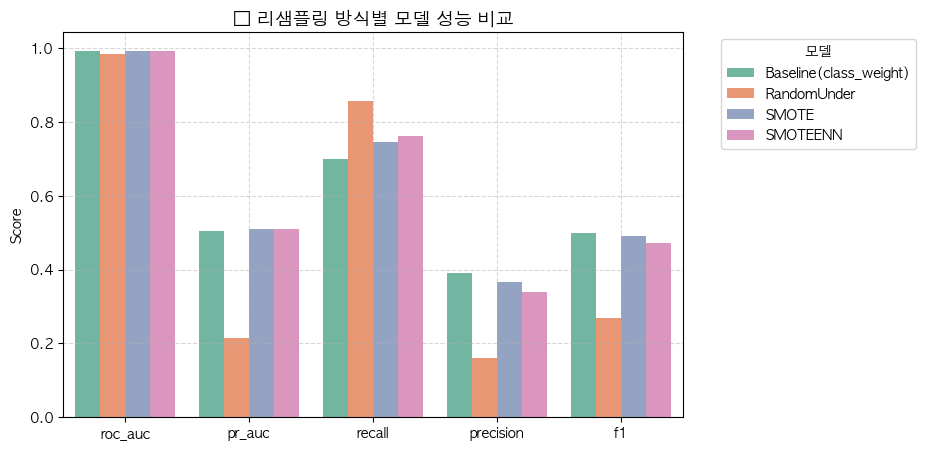

In [29]:
# ================================
# ⚡ AI 조기경보 모델 (Resampling 비교 + Best 모델 저장 + 시각화)
# ================================

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from lightgbm import log_evaluation, early_stopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    precision_score, recall_score, f1_score
)
import joblib

# imbalance 처리 라이브러리
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN


# -----------------------------
# 공통: 사용할 컬럼셋(업종/상권 제외) + 간단 전처리
# -----------------------------
# 1️⃣ 학습 데이터에서 '업종', '상권' 컬럼은 제외 (범주형/라벨인코딩 대상이므로 일단 제외)
use_cols = [c for c in X_train.columns if c not in ['업종', '상권']]

def prepare_xy(X, y, cols):
    """
    ⚙️ 리샘플링 및 모델 학습용 안전 전처리 함수
    ------------------------------------------------
    - 입력값:
        X : 독립변수(DataFrame)
        y : 종속변수(Series)
        cols : 사용할 컬럼 목록
    - 주요 처리:
        1. 지정된 컬럼만 선택 (업종/상권 등 제외)
        2. inf(무한대) → NaN으로 변환
        3. 숫자형 컬럼만 중앙값으로 결측치 대체
           (주의: SMOTE 같은 오버샘플링 기법은 NaN을 허용하지 않음)
    - 출력값:
        Xc : 전처리된 입력 데이터
        y  : 변경 없는 타깃값
    """
    Xc = X[cols].copy()
    Xc = Xc.replace([np.inf, -np.inf], np.nan)
    # 숫자 컬럼만 중앙값으로 채움 (SMOTE가 NaN을 못 받기 때문)
    num_cols = Xc.select_dtypes(include=[np.number]).columns
    Xc[num_cols] = Xc[num_cols].fillna(Xc[num_cols].median())
    return Xc, y

def _auto_fix_k_neighbors(sampler, y):
    """소수 클래스 개수에 맞춰 k_neighbors를 자동 보정"""
    try:
        from collections import Counter
        cnt = Counter(y)
        # 양성 클래스(1) 기준, 없으면 가장 적은 클래스 기준
        minority = min(cnt, key=cnt.get)
        m = cnt[minority]
        k = max(1, min(getattr(sampler, "k_neighbors", 5), m - 1))
        if hasattr(sampler, "k_neighbors"):
            sampler.k_neighbors = k
        if hasattr(sampler, "smote") and hasattr(sampler.smote, "k_neighbors"):
            sampler.smote.k_neighbors = k
    except Exception:
        pass
    return sampler



# -----------------------------
# 2️⃣ 학습 함수 정의
# -----------------------------
def fit_eval(X_train, y_train, X_test, y_test, sampler=None, name="baseline", use_class_weight=False):
    # 0) 전처리(업종/상권 제외 + NaN/inf 처리)
    X_tr, y_tr = prepare_xy(X_train, y_train, use_cols)
    X_te, y_te = prepare_xy(X_test,  y_test,  use_cols)

    # 1) 리샘플링 (필요 시 k_neighbors 자동 보정)
    X_res, y_res = X_tr, y_tr
    if sampler is not None:
        sampler = _auto_fix_k_neighbors(sampler, y_tr)
        X_res, y_res = sampler.fit_resample(X_tr, y_tr)

    # 2) 모델
    model = lgb.LGBMClassifier(
        objective='binary',
        learning_rate=0.03,
        n_estimators=2000,
        num_leaves=15,
        min_data_in_leaf=5,
        min_gain_to_split=0.0,
        class_weight=('balanced' if use_class_weight else None),
        random_state=42
    )
    model.fit(
        X_res, y_res,
        eval_set=[(X_te, y_te)],             # ✅ 같은 전처리/컬럼셋
        eval_metric='auc',
        callbacks=[log_evaluation(100), early_stopping(200)]
    )

    # 3) 평가
    proba = model.predict_proba(X_te)[:, 1]
    roc = roc_auc_score(y_te, proba)
    pr_auc = average_precision_score(y_te, proba)

    p, r, th = precision_recall_curve(y_te, proba)
    beta = 2
    # thresholds 길이는 p/r 보다 1 작음 → p[1:], r[1:]에 맞춰 F2 계산
    f2 = (1+beta**2)*p[1:]*r[1:] / (beta**2*p[1:] + r[1:] + 1e-12)
    if len(th) == 0:
        thr = 0.5
    else:
        best_i = int(np.nanargmax(f2))
        thr = th[best_i] if best_i < len(th) else 0.5
    y_pred = (proba >= thr).astype(int)

    return {
        "name": name,
        "model": model,
        "roc_auc": roc,
        "pr_auc": pr_auc,
        "precision": precision_score(y_te, y_pred, zero_division=0),
        "recall": recall_score(y_te, y_pred, zero_division=0),
        "f1": f1_score(y_te, y_pred, zero_division=0),
        "best_thr": thr
    }


# -----------------------------
# 3️⃣ 모델 비교 수행
# -----------------------------
results = []
results.append(fit_eval(X_train, y_train, X_test, y_test, sampler=None, name="Baseline(class_weight)", use_class_weight=True))
results.append(fit_eval(X_train, y_train, X_test, y_test, sampler=RandomUnderSampler(random_state=42), name="RandomUnder"))
results.append(fit_eval(X_train, y_train, X_test, y_test, sampler=SMOTE(random_state=42, k_neighbors=3), name="SMOTE"))
results.append(fit_eval(X_train, y_train, X_test, y_test, sampler=SMOTEENN(random_state=42, smote=SMOTE(random_state=42, k_neighbors=3)), name="SMOTEENN"))

# -----------------------------
# 4️⃣ 성능 비교 결과 정리
# -----------------------------
df_result = pd.DataFrame(results).drop(columns=["model"])
best_model_info = df_result.sort_values("pr_auc", ascending=False).iloc[0]
best_model_name = best_model_info["name"]
print("✅ Best Model:", best_model_name)
print(df_result.round(4))

# -----------------------------
# 5️⃣ Best 모델 저장
# -----------------------------
best_model = [r["model"] for r in results if r["name"] == best_model_name][0]
joblib.dump(best_model, f"best_lightgbm_{best_model_name}.pkl")
print(f"💾 '{best_model_name}' 모델이 저장되었습니다.")

# -----------------------------
# 6️⃣ 성능 시각화
# -----------------------------
plt.figure(figsize=(8,5))
sns.barplot(data=df_result.melt(id_vars=["name"], value_vars=["roc_auc", "pr_auc", "recall", "precision", "f1"]),
            x="variable", y="value", hue="name", palette="Set2")
plt.title("📊 리샘플링 방식별 모델 성능 비교", fontsize=13)
plt.ylabel("Score")
plt.xlabel("")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="모델", bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()


# 모델 스태킹

In [30]:

# ============================================================
# ✅ 시계열 분할 + 공통 전처리 + OOF Stacking + Hold-out Test 평가
#    (업종/상권은 feature에서 제외: use_cols)
# ============================================================

import warnings, numpy as np, pandas as pd
from dataclasses import dataclass
from typing import List, Tuple

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, average_precision_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

# -----------------------------
# 0) 컬럼 이름
# -----------------------------
ID = '가맹점구분번호'
DATE = '기준년월'
TARGET = 'next_month_crisis'

# ============================================================
# 1) 데이터 준비 (df가 이미 존재한다고 가정)
# ============================================================
df = df.copy()

# 날짜 파싱 및 시계열 정렬
df[DATE] = pd.to_datetime(df[DATE], errors='coerce')
df = df.sort_values(DATE)
print("📅 기간:", df[DATE].min(), "→", df[DATE].max())

# -----------------------------
# Hold-out Test: 최근 3개월
# -----------------------------
months = np.sort(df[DATE].dropna().dt.to_period('M').unique())
test_months = months[-3:] if len(months) >= 3 else months[-1:]
print("🗓️ 테스트 대상 월:", list(map(str, test_months)))

is_test_month = df[DATE].dt.to_period('M').isin(test_months)
train_mask = ~is_test_month
test_mask = is_test_month

# -----------------------------
# Split & 불필요 컬럼 제거
# -----------------------------
drop_cols = [ID, DATE, '폐업일']  # 폐업일 누수 방지

X = df.drop(columns=[TARGET], errors='ignore')
y = df[TARGET].astype(int)

X_train, y_train = X.loc[train_mask].copy(), y.loc[train_mask].copy()
X_test,  y_test  = X.loc[test_mask].copy(),  y.loc[test_mask].copy()

X_train.drop(columns=drop_cols, inplace=True, errors='ignore')
X_test.drop(columns=drop_cols, inplace=True, errors='ignore')

# dtype 정리 (object → category)
for c in X_train.select_dtypes('object').columns:
    X_train[c] = X_train[c].astype('category')
    if c in X_test.columns:
        X_test[c]  = X_test[c].astype('category')

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# 업종/상권은 유지하되 '학습 입력'에서는 제외
use_cols = [c for c in X_train.columns if c not in ['업종', '상권']]


# ============================================================
# 2) 유틸 함수
# ============================================================
def find_best_threshold(y_true: np.ndarray, y_prob: np.ndarray, metric="f1") -> Tuple[float, float]:
    grid = np.linspace(0.01, 0.99, 99)
    best_t, best_m = 0.5, -1.0
    for t in grid:
        pred = (y_prob >= t).astype(int)
        if metric == "f1":
            m = f1_score(y_true, pred, zero_division=0)
        elif metric == "recall":
            m = recall_score(y_true, pred, zero_division=0)
        elif metric == "precision":
            m = precision_score(y_true, pred, zero_division=0)
        else:
            raise ValueError("metric must be one of: f1/recall/precision")
        if m > best_m:
            best_t, best_m = t, m
    return float(best_t), float(best_m)

def topk_metrics(y_true: np.ndarray, y_prob: np.ndarray, k_ratio: float = 0.1) -> Tuple[float, float]:
    n = len(y_true)
    k = max(1, int(np.ceil(n * k_ratio)))
    order = np.argsort(-y_prob, kind="mergesort")
    top_idx = order[:k]
    pred = np.zeros(n, dtype=int); pred[top_idx] = 1
    p = float(precision_score(y_true, pred, zero_division=0))
    r = float(recall_score(y_true, pred, zero_division=0))
    return p, r

@dataclass
class BaseModelSpec:
    name: str
    estimator: object

# ============================================================
# 3) 공통 전처리 (use_cols 기준)
#    - cat: most_frequent 대치 + OneHot
#    - num: median 대치
# ============================================================
def build_preprocess(X_fit: pd.DataFrame, cols: List[str]) -> ColumnTransformer:
    Xc = X_fit[cols]
    cat_cols = Xc.select_dtypes(include=['category', 'object']).columns.tolist()
    num_cols = [c for c in cols if c not in cat_cols]

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ])

    pre = ColumnTransformer(
        transformers=[
            ("cat", cat_pipe, cat_cols),
            ("num", num_pipe, num_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )
    return pre

# ============================================================
# 4) 베이스 모델들 (불균형 보정 포함)
# ============================================================
def build_base_models(preprocess: ColumnTransformer, pos_w: float) -> List[BaseModelSpec]:
    lgbm1 = LGBMClassifier(
        objective="binary",
        n_estimators=600, learning_rate=0.03, num_leaves=63,
        min_child_samples=40, subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=pos_w, random_state=RANDOM_STATE
    )
    xgb1 = XGBClassifier(
        objective="binary:logistic",
        n_estimators=700, learning_rate=0.03, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
        scale_pos_weight=pos_w, eval_metric="auc", tree_method="hist",
        random_state=RANDOM_STATE
    )
    cat1 = CatBoostClassifier(
        loss_function="Logloss", eval_metric="AUC",
        depth=6, learning_rate=0.04, iterations=800,
        subsample=0.8, l2_leaf_reg=3.0, scale_pos_weight=pos_w,
        verbose=False, random_state=RANDOM_STATE
    )
    xgb2 = XGBClassifier(
        objective="binary:logistic",
        n_estimators=900, learning_rate=0.025, max_depth=5,
        subsample=0.7, colsample_bytree=0.9, reg_lambda=1.5,
        scale_pos_weight=pos_w, eval_metric="auc", tree_method="hist",
        random_state=RANDOM_STATE + 7
    )

    specs = [
        BaseModelSpec("lgbm1", Pipeline([("prep", preprocess), ("clf", lgbm1)])),
        BaseModelSpec("xgb1",  Pipeline([("prep", preprocess), ("clf", xgb1)])),
        BaseModelSpec("cat1",  Pipeline([("prep", preprocess), ("clf", cat1)])),
        BaseModelSpec("xgb2",  Pipeline([("prep", preprocess), ("clf", xgb2)])),
    ]
    return specs

# ============================================================
# 5) OOF Stacking (Train 내부에서만)
# ============================================================
def run_oof_stacking(
    X_tr: pd.DataFrame, y_tr: np.ndarray,
    preprocess: ColumnTransformer,
    n_splits: int = 5, meta_type: str = "lgbm", passthrough: bool = False
):
    # 불균형 가중
    pos_w = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)

    base_specs = build_base_models(preprocess, pos_w)
    n_models = len(base_specs)
    oof_stack = np.zeros((len(X_tr), n_models), dtype=float)

    tscv = TimeSeriesSplit(n_splits=n_splits)

    # 5-1) 베이스별 OOF
    for m_idx, spec in enumerate(base_specs):
        name, model = spec.name, spec.estimator
        print(f"\n[OOF] base={name}")
        oof_col = np.zeros(len(X_tr), dtype=float)

        for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_tr), 1):
            X_fold_tr = X_tr.iloc[tr_idx][use_cols]
            X_fold_va = X_tr.iloc[va_idx][use_cols]
            y_fold_tr, y_fold_va = y_tr[tr_idx], y_tr[va_idx]

            model.fit(X_fold_tr, y_fold_tr)
            oof_col[va_idx] = model.predict_proba(X_fold_va)[:, 1]
            auc = roc_auc_score(y_fold_va, oof_col[va_idx])
            print(f"  - fold{fold} AUC = {auc:.4f}")

        oof_auc = roc_auc_score(y_tr, oof_col)
        print(f"  - OOF AUC({name}) = {oof_auc:.4f}")
        oof_stack[:, m_idx] = oof_col

    # 5-2) 메타 입력 구성
    if passthrough:
        first_prep = base_specs[0].estimator.named_steps["prep"]
        X_transformed = first_prep.fit_transform(X_tr[use_cols])
        meta_X = np.hstack([oof_stack, X_transformed])
    else:
        meta_X = oof_stack

    # 5-3) 메타모델 학습
    if meta_type == "logit":
        meta = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
    elif meta_type == "lgbm":
        meta = LGBMClassifier(
            objective="binary", n_estimators=300, learning_rate=0.05,
            num_leaves=15, min_child_samples=50, subsample=0.9, colsample_bytree=0.8,
            class_weight="balanced", random_state=RANDOM_STATE
        )
    else:
        raise ValueError("meta_type must be 'logit' or 'lgbm'")

    meta.fit(meta_X, y_tr)
    meta_oof = meta.predict_proba(meta_X)[:, 1]
    meta_auc = roc_auc_score(y_tr, meta_oof)
    pr_auc = average_precision_score(y_tr, meta_oof)
    print(f"\n[META OOF] AUC={meta_auc:.4f}  PR-AUC={pr_auc:.4f}")

    # 5-4) 배포용 베이스(Train 전체로 재학습)
    fitted_bases = []
    for spec in build_base_models(preprocess, pos_w):
        mdl = spec.estimator.fit(X_tr[use_cols], y_tr)
        fitted_bases.append((spec.name, mdl))

    # 예측 함수
    def predict_stacked(X_new: pd.DataFrame) -> np.ndarray:
        base_probs = []
        for _, mdl in fitted_bases:
            p = mdl.predict_proba(X_new[use_cols])[:, 1]
            base_probs.append(p)
        base_probs = np.column_stack(base_probs)

        if passthrough:
            first_prep = fitted_bases[0][1].named_steps["prep"]
            X_new_trans = first_prep.transform(X_new[use_cols])
            meta_in = np.hstack([base_probs, X_new_trans])
        else:
            meta_in = base_probs

        return meta.predict_proba(meta_in)[:, 1]

    return meta_oof, predict_stacked

# ============================================================
# 6) 실행: Train OOF → Hold-out Test 평가
# ============================================================
# 공통 전처리(Train에 맞춰 fit)
preprocess = build_preprocess(X_train, use_cols)

# OOF 스태킹 (Train 내부)
meta_oof, predict_fn = run_oof_stacking(
    X_tr=X_train, y_tr=y_train.values,
    preprocess=preprocess,
    n_splits=5, meta_type="lgbm", passthrough=False
)

# Train OOF 기준 임계값 최적화(F1)
best_thr, best_f1 = find_best_threshold(y_train.values, meta_oof, metric="f1")
print(f"[Train-OOF Best(F1)] t={best_thr:.3f}, F1={best_f1:.4f}")

# -----------------------------
# Hold-out Test 평가
# -----------------------------
y_prob_test = predict_fn(X_test)
test_auc   = roc_auc_score(y_test, y_prob_test)
test_pr    = average_precision_score(y_test, y_prob_test)

y_hat_test = (y_prob_test >= best_thr).astype(int)
test_p  = precision_score(y_test, y_hat_test, zero_division=0)
test_r  = recall_score(y_test, y_hat_test, zero_division=0)
test_f1 = f1_score(y_test, y_hat_test, zero_division=0)

print("\n=== 📊 Hold-out Test (최근 3개월) ===")
print(f"AUC={test_auc:.4f}  PR-AUC={test_pr:.4f}")
print(f"Precision={test_p:.4f}  Recall={test_r:.4f}  F1={test_f1:.4f}")

for k in [0.05, 0.10, 0.20]:
    p_atk, r_atk = topk_metrics(y_test.values, y_prob_test, k_ratio=k)
    print(f"[Top-{int(100*k)}%] Precision={p_atk:.4f}, Recall={r_atk:.4f}")

print("\nProb range:", float(y_prob_test.min()), float(y_prob_test.max()))
print("Quantiles 50/80/90/95/99:", np.quantile(y_prob_test, [0.5, 0.8, 0.9, 0.95, 0.99]))

📅 기간: 2023-01-01 00:00:00 → 2024-11-01 00:00:00
🗓️ 테스트 대상 월: ['2024-09', '2024-10', '2024-11']
Train: (52851, 54), Test: (9182, 54)

[OOF] base=lgbm1
[LightGBM] [Info] Number of positive: 37, number of negative: 8774
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002079 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9592
[LightGBM] [Info] Number of data points in the train set: 8811, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.004199 -> initscore=-5.468630
[LightGBM] [Info] Start training from score -5.468630
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

In [31]:

import numpy as np

def _best_threshold(y_true, y_prob, metric="f1"):
    grid = np.linspace(0.01, 0.99, 99)
    best_t, best_m = 0.5, -1.0
    for t in grid:
        pred = (y_prob >= t).astype(int)
        if metric == "f1":
            m = f1_score(y_true, pred, zero_division=0)
        elif metric == "precision":
            m = precision_score(y_true, pred, zero_division=0)
        elif metric == "recall":
            m = recall_score(y_true, pred, zero_division=0)
        else:
            raise ValueError("metric must be one of: f1/precision/recall")
        if m > best_m:
            best_t, best_m = t, m
    return best_t, best_m

def _topk_metrics(y_true, y_prob, k_ratio):
    n = len(y_true)
    k = max(1, int(np.ceil(n * k_ratio)))
    order = np.argsort(-y_prob, kind="mergesort")
    pred = np.zeros(n, dtype=int); pred[order[:k]] = 1
    p = precision_score(y_true, pred, zero_division=0)
    r = recall_score(y_true, pred, zero_division=0)
    return p, r

def summarize_performance(title, y_true, y_prob, topks=(0.05, 0.1, 0.2), thr_metric="f1"):
    auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    best_thr, best_score = _best_threshold(y_true, y_prob, metric=thr_metric)
    y_hat = (y_prob >= best_thr).astype(int)
    pre = precision_score(y_true, y_hat, zero_division=0)
    rec = recall_score(y_true, y_hat, zero_division=0)
    f1  = f1_score(y_true, y_hat, zero_division=0)

    print("\n" + "="*60)
    print(f"📊 {title}")
    print("="*60)
    print(f"AUC                      : {auc:.4f}")
    print(f"PR-AUC                   : {pr_auc:.4f}")
    print(f"Best Threshold ({thr_metric.upper()} 기준) : {best_thr:.3f}")
    print(f"F1 Score                 : {f1:.4f}")
    print(f"Precision                : {pre:.4f}")
    print(f"Recall                   : {rec:.4f}")
    print("-"*60)
    for k in topks:
        p_atk, r_atk = _topk_metrics(y_true, y_prob, k_ratio=k)
        print(f"Top-{int(k*100)}% Precision={p_atk:.4f} | Recall={r_atk:.4f}")
    print("="*60)

    return {
        "auc": auc, "pr_auc": pr_auc, "best_thr": best_thr,
        "precision": pre, "recall": rec, "f1": f1
    }

def rank_and_print(models, key="pr_auc", thr_metric="f1"):
    """
    models: [(name, y_true, y_prob), ...]
    key   : 'pr_auc' | 'auc' | 'f1' 중 선택해 랭킹
    """
    scores = []
    for name, yt, yp in models:
        res = summarize_performance(name, yt, yp, thr_metric=thr_metric)
        scores.append((name, res[key]))
    best = max(scores, key=lambda x: x[1])
    print(f"\n🏆 Best Model by {key.upper()}: {best[0]}  ({key}={best[1]:.4f})")
    return best[0]



In [32]:
# Hold-out Test 성능 요약
summarize_performance("STACKING MODEL (Hold-out Test: 최근 3개월)", y_test.values, y_prob_test)

# (옵션) 여러 후보 비교 후 최고 모델 프린트
# rank_and_print([
#     ("Baseline LGBM", y_test.values, y_prob_baseline),
#     ("STACKING",      y_test.values, y_prob_test),
#     ("Another",       y_test.values, y_prob_other),
# ], key="pr_auc")


📊 STACKING MODEL (Hold-out Test: 최근 3개월)
AUC                      : 0.9900
PR-AUC                   : 0.4238
Best Threshold (F1 기준) : 0.990
F1 Score                 : 0.5224
Precision                : 0.4930
Recall                   : 0.5556
------------------------------------------------------------
Top-5% Precision=0.1283 | Recall=0.9365
Top-10% Precision=0.0686 | Recall=1.0000
Top-20% Precision=0.0343 | Recall=1.0000


{'auc': 0.990013002678865,
 'pr_auc': 0.42375964937580574,
 'best_thr': 0.99,
 'precision': 0.49295774647887325,
 'recall': 0.5555555555555556,
 'f1': 0.5223880597014925}

# Recall 최대 임계값 조정

In [33]:
def scan_thresholds(y_true, y_prob, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.1, 0.99, 90)  # 균등하게 0.1~0.99
    recs = []
    for t in thresholds:
        pred = (y_prob >= t).astype(int)
        p = precision_score(y_true, pred, zero_division=0)
        r = recall_score(y_true, pred, zero_division=0)
        f = f1_score(y_true, pred, zero_division=0)
        recs.append({"threshold": float(t), "precision": p, "recall": r, "f1": f})
    return pd.DataFrame(recs)


# ✅ OOF(Train) 기준 스캔
df_scan_oof = scan_thresholds(y_train.values, meta_oof)
df_scan_oof

,threshold,precision,recall,f1
0,0.10,0.029096,1.000000,0.056547
1,0.11,0.029175,1.000000,0.056696
2,0.12,0.029274,1.000000,0.056882
3,0.13,0.029356,1.000000,0.057038
4,0.14,0.029437,1.000000,0.057190
...,...,...,...,...
85,0.95,0.418605,0.750000,0.537313
86,0.96,0.444444,0.692308,0.541353
87,0.97,0.441315,0.602564,0.509485
88,0.98,0.496894,0.512821,0.504732


In [34]:
# ✅ 0.8 ~ 0.95 구간만 추출
focus_df = df_scan_oof.query("0.55 <= threshold <= 0.85").copy()

# 보기 좋게 정렬 및 반올림
focus_df = focus_df.round(4)
display(focus_df)




,threshold,precision,recall,f1
45,0.55,0.2223,0.8814,0.3551
46,0.56,0.2243,0.8814,0.3576
47,0.57,0.2262,0.8814,0.3599
48,0.58,0.2280,0.8814,0.3623
49,0.59,0.2311,0.8814,0.3662
50,0.60,0.2331,0.8814,0.3686
51,0.61,0.2346,0.8814,0.3706
52,0.62,0.2367,0.8814,0.3731
53,0.63,0.2389,0.8814,0.3759
54,0.64,0.2427,0.8814,0.3806


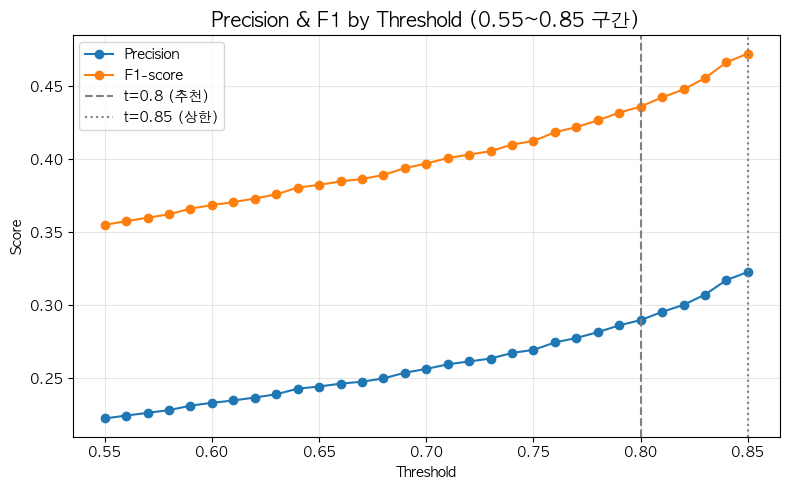

In [35]:
focus = df_scan_oof.query("0.55 <= threshold <= 0.85").copy()

plt.figure(figsize=(8,5))
plt.plot(focus["threshold"], focus["precision"], 'o-', label="Precision", color='tab:blue')
plt.plot(focus["threshold"], focus["f1"], 'o-', label="F1-score", color='tab:orange')

plt.axvline(0.8, color='gray', linestyle='--', label="t=0.8 (추천)")
plt.axvline(0.85, color='gray', linestyle=':', label="t=0.85 (상한)")

plt.title("Precision & F1 by Threshold (0.55~0.85 구간)", fontsize=14, weight='bold')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [36]:
# (옵션) ✅ Hold-out Test 기준 스캔
df_scan_test = scan_thresholds(y_test.values, y_prob_test)
df_scan_test


# ✅ 0.8 ~ 0.95 구간만 추출
focus_df_test = df_scan_test.query("0.55 <= threshold <= 0.85").copy()

# 보기 좋게 정렬 및 반올림
focus_df_test = focus_df_test.round(4)
display(focus_df_test)

,threshold,precision,recall,f1
45,0.55,0.1492,0.9048,0.2562
46,0.56,0.1500,0.9048,0.2573
47,0.57,0.1512,0.9048,0.2591
48,0.58,0.1528,0.9048,0.2615
49,0.59,0.1536,0.9048,0.2627
50,0.60,0.1545,0.9048,0.2639
51,0.61,0.1557,0.9048,0.2657
52,0.62,0.1575,0.9048,0.2682
53,0.63,0.1579,0.9048,0.2689
54,0.64,0.1592,0.9048,0.2708


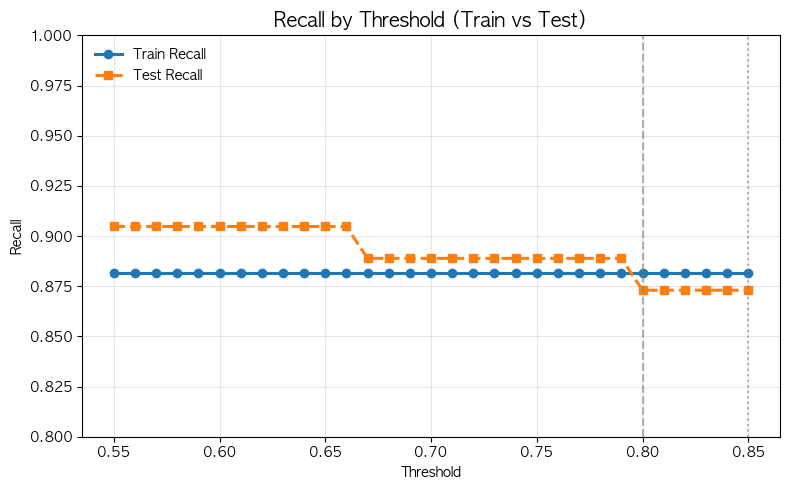

In [37]:
import matplotlib.pyplot as plt

focus_train = df_scan_oof.query("0.55 <= threshold <= 0.85").copy()
focus_test = df_scan_test.query("0.55 <= threshold <= 0.85").copy()

plt.figure(figsize=(8,5))
plt.plot(focus_train["threshold"], focus_train["recall"],
         color="#1f77b4", marker='o', linestyle='-', linewidth=2.2,
         label="Train Recall")
plt.plot(focus_test["threshold"], focus_test["recall"],
         color="#ff7f0e", marker='s', linestyle='--', linewidth=2.2,
         label="Test Recall")

plt.axvline(0.8, color='gray', linestyle='--', alpha=0.6)
plt.axvline(0.85, color='gray', linestyle=':', alpha=0.6)

plt.title("Recall by Threshold (Train vs Test)", fontsize=14, weight='bold')
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.ylim(0.8, 1.0)
plt.legend(loc="upper left", frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()




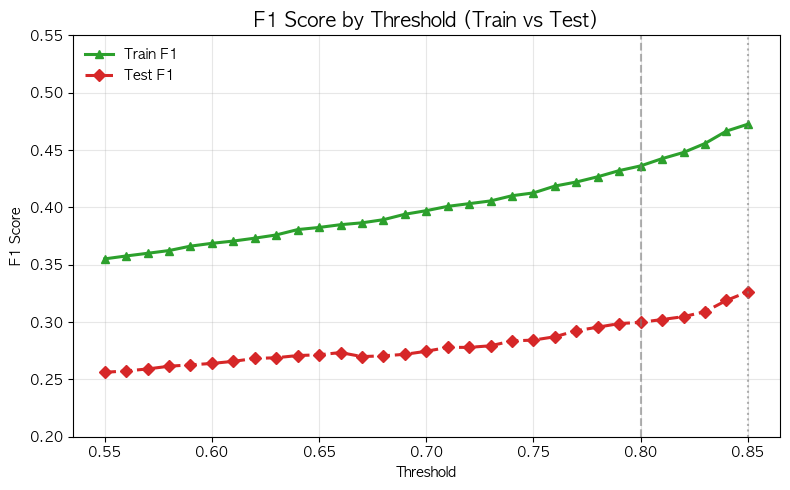

In [38]:
plt.figure(figsize=(8,5))
plt.plot(focus_train["threshold"], focus_train["f1"],
         color="#2ca02c", marker='^', linestyle='-', linewidth=2.2,
         label="Train F1")
plt.plot(focus_test["threshold"], focus_test["f1"],
         color="#d62728", marker='D', linestyle='--', linewidth=2.2,
         label="Test F1")

plt.axvline(0.8, color='gray', linestyle='--', alpha=0.6)
plt.axvline(0.85, color='gray', linestyle=':', alpha=0.6)

plt.title("F1 Score by Threshold (Train vs Test)", fontsize=14, weight='bold')
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.ylim(0.2, 0.55)
plt.legend(loc="upper left", frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Threshold 0.85 기준 top - 5%

In [39]:
t = 0.85
n = len(y_prob_test)
n_ge_t = int((y_prob_test >= t).sum())
rate_ge_t = n_ge_t / n

print(f"≥ {t} 개수: {n_ge_t} / {n} ({rate_ge_t:.2%})")


≥ 0.85 개수: 274 / 9182 (2.98%)


In [40]:
t = 0.75
n = len(y_prob_test)
n_ge_t = int((y_prob_test >= t).sum())
rate_ge_t = n_ge_t / n

print(f"≥ {t} 개수: {n_ge_t} / {n} ({rate_ge_t:.2%})")

≥ 0.75 개수: 331 / 9182 (3.60%)


## 위험 점포 선정 방식
- A리스트: ≥0.75 전부 (최우선)
- B리스트: 부족분은 다음 고득점부터 K까지 채움

In [41]:
# drop했던 가맹점 구분번호 복원
# X_test의 인덱스를 이용해 원본 df에서 가맹점번호를 붙이기
df_test_with_id = X_test.join(df['가맹점구분번호'], how='left')

# 컬럼 재정렬
cols = ['가맹점구분번호'] + [c for c in df_test_with_id.columns if c != '가맹점구분번호']
df_test_with_id = df_test_with_id.reindex(columns=cols)

df_test_with_id['y_prob'] = y_prob_test
df_test_with_id['y_true'] = y_test.values  # 또는 np.asarray(y_test)
# 확인
df_test_with_id

,가맹점구분번호,매출금액구간,유니크고객수구간,객단가구간,취소율구간,배달매출비율,동일업종 매출비율,동일업종 매출건수 비율,동일 업종 내 매출 순위 비율,동일 업종 내 해지 가맹점 비중,...,연령_40대,연령_50대,연령_60대이상,연령_20대이하_3개월변화,연령_30대_3개월변화,연령_40대_3개월변화,연령_50대_3개월변화,연령_60대이상_3개월변화,y_prob,y_true
58098,EE7D3593F6,4.0,5,1,1,0.0,0.584,0.097,12.7,15.9,...,20.2,12.4,11.2,1.3,-4.1,-0.3,3.4,-0.3,0.000324,0
54867,E427B5E29F,3.0,1,4,6,0.0,1.748,4.018,9.7,17.1,...,10.1,11.0,4.7,-0.9,0.5,0.1,0.3,0.0,0.000215,0
54309,E19118E99D,2.0,3,2,1,26.2,2.647,1.014,5.4,17.1,...,9.4,9.3,3.2,-2.0,1.7,-0.6,0.8,0.2,0.000215,0
18727,49F556B92E,5.0,3,5,1,0.0,0.158,0.870,57.4,17.1,...,16.3,24.8,25.5,0.1,0.6,-0.7,-1.5,1.5,0.000215,0
1361,0507C6C859,5.0,4,4,1,64.1,0.165,0.329,50.9,17.1,...,18.4,11.6,4.7,0.4,0.8,-2.6,1.6,-0.3,0.000215,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32041,827A8265A3,6.0,5,4,1,98.4,0.029,0.027,66.2,15.4,...,28.4,22.4,4.5,-1.8,2.6,-0.4,-0.3,0.0,0.000255,0
10743,2A74299DD1,3.0,3,2,1,0.0,3.151,1.578,3.2,16.7,...,6.4,9.5,3.0,-1.7,1.0,-0.5,0.3,0.7,0.000303,0
32024,825CCFE2CE,2.0,4,1,1,0.0,1.611,0.395,4.7,12.0,...,10.5,24.3,33.0,-1.5,2.9,-0.8,-0.6,0.0,0.000557,0
49718,CB17914E57,1.0,1,3,4,0.0,4.458,8.523,1.7,17.7,...,8.5,10.8,1.6,-0.4,0.2,0.0,0.1,0.0,0.000323,0


In [42]:
from typing import Optional, Tuple
import numpy as np
import pandas as pd

def two_tier_select_recall(
    ids: np.ndarray,
    scores: np.ndarray,
    K: int,
    t: float = 0.85,
    y_true: Optional[np.ndarray] = None,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    ids     : 샘플 ID (길이 N)
    scores  : 예측 점수 (길이 N)
    K       : 최종 점검 대상 수
    t       : 임계값 (A리스트 기준, 기본 0.85)
    y_true  : (옵션) 정답 레이블 (길이 N, 0/1). 주면 tier별/전체 성능 계산에 사용

    return  : (df_A, df_B, df_selected)
              df_selected = A + B (최대 K개, 점수 내림차순)
    """
    N = len(scores)
    assert len(ids) == N, "ids와 scores 길이가 다릅니다."
    if y_true is not None:
        assert len(y_true) == N, "y_true 길이가 다릅니다."

    # 전체 데이터프레임
    df = pd.DataFrame({"id": ids, "score": scores})
    if y_true is not None:
        df["y"] = y_true

    # A: 임계값 이상 전부
    df_A = df.loc[df["score"] >= t].copy()
    df_A.sort_values("score", ascending=False, inplace=True)
    df_A["tier"] = "A"

    # B: K를 못 채우면, 임계값 미만에서 상위 점수로 보충
    need = max(0, K - len(df_A))
    if need > 0:
        df_b_cand = df.loc[df["score"] < t].copy()
        df_b_cand.sort_values("score", ascending=False, inplace=True)
        df_B = df_b_cand.head(need).copy()
        df_B["tier"] = "B"
    else:
        # A가 이미 K개 이상이면 B는 비움, A에서 K개만 유지
        df_B = df.iloc[0:0].copy()  # 빈 DF
        df_A = df_A.head(K)

    # 최종 선택(점수 내림차순 정렬 및 순위 부여)
    df_selected = pd.concat([df_A, df_B], axis=0, ignore_index=True)
    df_selected.sort_values(["tier","score"], ascending=[True, False], inplace=True)  # A 먼저
    df_selected["rank_overall"] = np.arange(1, len(df_selected) + 1)

    # (옵션) 성능지표 계산
    if y_true is not None:
        total_pos = int(np.sum(y_true))  # 전체 양성 수

        def _metrics(sub):
            tp = int(sub["y"].sum())
            n = len(sub)
            recall = tp / total_pos if total_pos > 0 else 0.0
            precision = tp / n if n > 0 else 0.0
            return pd.Series({"n": n, "tp": tp, "recall": recall, "precision": precision})

        m_A = _metrics(df_selected[df_selected["tier"]=="A"])
        m_B = _metrics(df_selected[df_selected["tier"]=="B"])
        m_all = _metrics(df_selected)

        # 전체 Recall/F1 계산
        pred = np.zeros(N, dtype=int)
        idx_sel = df.merge(df_selected[["id"]], on="id", how="inner").index.values
        pred[idx_sel] = 1

        tp_all = int((pred * y_true).sum())
        fn_all = int(((1 - pred) * y_true).sum())
        fp_all = int((pred * (1 - y_true)).sum())
        recall_all = tp_all / (tp_all + fn_all) if (tp_all + fn_all) > 0 else 0.0
        precision_all = tp_all / (tp_all + fp_all) if (tp_all + fp_all) > 0 else 0.0
        f1_all = 2*precision_all*recall_all/(precision_all+recall_all) if (precision_all+recall_all)>0 else 0.0

        print(f"[A] n={m_A['n']}, recall={m_A['recall']:.4f}, precision={m_A['precision']:.4f}")
        print(f"[B] n={m_B['n']}, recall={m_B['recall']:.4f}, precision={m_B['precision']:.4f}")
        print(f"[ALL] n={m_all['n']}, recall={recall_all:.4f}, precision={precision_all:.4f}, f1={f1_all:.4f}")

    return df_A, df_B, df_selected


# threshold 0.85 + top 5

In [43]:
# 예시: 테스트 세트에 적용
# ids_test: 샘플 ID 배열 (예: 상점 ID)
# y_prob_test: 모델 예측 점수
# y_test: (옵션) 정답 0/1
# K: 점검할 총 건수 (예: 상위 5%면 int(len(y_prob_test)*0.05))

K = int(len(y_prob_test) * 0.05)  # 상위 5% 점검 예시
t = 0.85                          # 보수 기준 고정
ids_test = df_test_with_id['가맹점구분번호'].values

df_A, df_B, df_sel = two_tier_select_recall(
    ids=ids_test,
    scores=y_prob_test,
    K=K,
    t=t,
    y_true=y_test.values   # ✅ 핵심: values로 전달
)

# 상위 몇 건 미리보기
print("A리스트 미리보기:")
display(df_A.head(10))

print("B리스트(보충) 미리보기:")
display(df_B.head(10))

print("최종 선택):")
display(df_sel)


[A] n=274.0, recall=0.8730, precision=0.2007
[B] n=185.0, recall=0.0635, precision=0.0216
[ALL] n=459.0, recall=0.2063, precision=0.0096, f1=0.0183
A리스트 미리보기:


,id,score,y,tier
6347,9B6F07D54C,0.997365,1,A
1371,6780FF33B7,0.997365,1,A
4647,E5474E6047,0.997365,0,A
1736,8E2D448FF9,0.997365,0,A
5317,B93D0BD7EA,0.997365,0,A
8177,C6C9F3F826,0.997365,0,A
8175,F34A09F515,0.997365,0,A
8090,F259ACF16D,0.997365,0,A
8020,DAFBA48973,0.997365,0,A
7630,4B5922FA5E,0.997365,1,A


B리스트(보충) 미리보기:


,id,score,y,tier
1607,A3801B70AE,0.848138,0,B
4507,4251F43180,0.844480,0,B
4773,3EB675E82D,0.844387,0,B
1264,433F5BCED5,0.844301,0,B
1734,C74C8A6CB8,0.843318,0,B
1275,2DCC4A585C,0.842352,0,B
220,255821302B,0.841022,0,B
1724,5E86C12B37,0.840206,0,B
4350,BEFFE2D107,0.838399,0,B
2785,9869644D22,0.838316,0,B


최종 선택):


,id,score,y,tier,rank_overall
0,9B6F07D54C,0.997365,1,A,1
1,6780FF33B7,0.997365,1,A,2
2,E5474E6047,0.997365,0,A,3
3,8E2D448FF9,0.997365,0,A,4
4,B93D0BD7EA,0.997365,0,A,5
...,...,...,...,...,...
454,3AB4FC1262,0.276628,0,B,455
455,45E84CAA54,0.271220,0,B,456
456,83A0FDAFA7,0.269131,0,B,457
457,1CAA6D7F95,0.268274,0,B,458


# threshold 0.80 + top 5

In [44]:
# 예시: 테스트 세트에 적용
# ids_test: 샘플 ID 배열 (예: 상점 ID)
# y_prob_test: 모델 예측 점수
# y_test: (옵션) 정답 0/1
# K: 점검할 총 건수 (예: 상위 5%면 int(len(y_prob_test)*0.05))

K = int(len(y_prob_test) * 0.05)  # 상위 5% 점검 예시
t = 0.80                          # 보수 기준 고정
ids_test = df_test_with_id['가맹점구분번호'].values

df_A, df_B, df_sel = two_tier_select_recall(
    ids=ids_test,
    scores=y_prob_test,
    K=K,
    t=t,
    y_true=y_test.values   # ✅ 핵심: values로 전달
)

# 상위 몇 건 미리보기
print("A리스트 미리보기:")
display(df_A.head(10))

print("B리스트(보충) 미리보기:")
display(df_B.head(10))

print("최종 선택):")
display(df_sel)

[A] n=304.0, recall=0.8730, precision=0.1809
[B] n=155.0, recall=0.0635, precision=0.0258
[ALL] n=459.0, recall=0.2063, precision=0.0096, f1=0.0183
A리스트 미리보기:


,id,score,y,tier
3653,CE0E9B9A73,0.997365,1,A
7630,4B5922FA5E,0.997365,1,A
6347,9B6F07D54C,0.997365,1,A
6292,1676020CB1,0.997365,1,A
949,2B2AD47693,0.997365,1,A
1030,1C9BB3C08A,0.997365,1,A
6104,155685F58E,0.997365,1,A
2225,823EAE1BFC,0.997365,0,A
1131,2A46B78747,0.997365,0,A
5658,7727CDA849,0.997365,0,A


B리스트(보충) 미리보기:


,id,score,y,tier
4620,B2A570260C,0.798517,0,B
4746,68F1BBE833,0.798198,0,B
5961,3AE0B97C20,0.798198,0,B
7167,41A48AF8FE,0.797174,0,B
2663,55B960CBD0,0.793272,1,B
4086,A523C21333,0.793272,0,B
5744,77E24452D3,0.791461,0,B
5708,A92743CA52,0.790121,0,B
4782,67BEA11D33,0.786670,0,B
401,1EC6CCBA67,0.786194,0,B


최종 선택):


,id,score,y,tier,rank_overall
0,CE0E9B9A73,0.997365,1,A,1
1,4B5922FA5E,0.997365,1,A,2
2,9B6F07D54C,0.997365,1,A,3
3,1676020CB1,0.997365,1,A,4
4,2B2AD47693,0.997365,1,A,5
...,...,...,...,...,...
454,3AB4FC1262,0.276628,0,B,455
455,45E84CAA54,0.271220,0,B,456
456,83A0FDAFA7,0.269131,0,B,457
457,1CAA6D7F95,0.268274,0,B,458
